Ce notebook est celui que j'ai utilisé pendant le stage SHREQ pour analyse les images de température Landsat téléchargées via le script pour l'api js de GEE download_landsat.js présent dans le même dossier.  
Ce notebook contient des codes qui m'ont servi à plusieurs choses :  
- visualiser les images
- analyser les heures, dates d'acquisition
- analyser le nombre d'acquisitions sur la zone d'étude à différents pas de temps, pour chercher l'aggrégat temporel pertinent
- exporter les médianes saisonnières restreintes au roi défini et aux tuiles retenues, pour les utiliser dans le modèle
- exporter des images et des données utilisables par une carte web avec api python de visualisation des lst réalisée pendant le stage. Parmi ces données exportées, il y a le fichier landsat_img_stack.pt présent dans le dossier données du dossier de ce stage qui est un stack de toutes les images landsat chargeable via pytorch.load.

In [ ]:
import numpy as np
import rasterio
import torch
import matplotlib.pyplot as plt
import os
from os.path import join
import glob
import joblib
import pandas as pd
import geopandas as gpd
from concurrent.futures import ProcessPoolExecutor
import shreklib
import time
import tqdm
import shapely
import datetime
import matplotlib.ticker as mticker
from rasterio import windows
import geopandas as gpd
import shapely
import affine
from rasterio.features import rasterize
from affine import Affine
import tqdm

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
# dossier contennant les images téléchargées depuis gee
lst_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022"
lst_fps=glob.glob(join(lst_folder, "**", "**","*.tif"))


In [ ]:
def load_lst(fp):
    chunk={}
    with rasterio.open(fp, "r") as src:
        full_imgs=torch.from_numpy(src.read().astype(np.float16))
        not_empty_mask=~torch.all(torch.isnan(full_imgs), dim=(1,2))
        chunk["imgs"]=full_imgs[not_empty_mask]
        chunk["transform"]=src.transform
        chunk["noms"]=np.array(src.descriptions)[not_empty_mask]
        chunk["fp"]=fp
    return chunk

In [ ]:
chunks=[]
start_loop=time.time()
for fp in tqdm.tqdm(lst_fps):
    start_load=time.time()
    chunks.append(load_lst(fp))
    print(f"image {fp} chargée en {int((time.time()-start_load)//60)}m {round((time.time()-start_load)%60)}s")
print(f"Temps de chargement complet : {int((time.time()-start_loop)//60)}s et {round((time.time()-start_loop)%60)}s")

  3%|██████▎                                                                                                                                                                                                  | 1/32 [00:50<26:14, 50.79s/it]

image /mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/LST_Landsat_salade-20260622T133630Z-3-003/LST_Landsat_salade/LST_Landsat_2019-01-01_a_2021-07-03_chunk1of2-0000001280-0000005120.tif chargée en 0.0m 50.78543519973755s


  6%|████████████▌                                                                                                                                                                                            | 2/32 [02:19<36:28, 72.94s/it]

image /mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/LST_Landsat_salade-20260622T133630Z-3-003/LST_Landsat_salade/LST_Landsat_2019-01-01_a_2021-07-03_chunk1of2-0000000000-0000002560.tif chargée en 1.0m 28.44638180732727s


  9%|██████████████████▊                                                                                                                                                                                      | 3/32 [03:48<38:53, 80.47s/it]

...

image /mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/LST_Landsat_salade-20260622T133630Z-3-002/LST_Landsat_salade/LST_Landsat_2019-01-01_a_2021-07-03_chunk1of2-0000000000-0000001280.tif chargée en 1.0m 21.458596229553223s


 94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌            | 30/32 [38:12<02:33, 76.97s/it]

image /mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/LST_Landsat_salade-20260622T133630Z-3-002/LST_Landsat_salade/LST_Landsat_2019-01-01_a_2021-07-03_chunk1of2-0000001280-0000002560.tif chargée en 1.0m 28.111836910247803s


 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊      | 31/32 [39:09<01:10, 70.98s/it]

image /mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/LST_Landsat_salade-20260622T133630Z-3-002/LST_Landsat_salade/LST_Landsat_2019-01-01_a_2021-07-03_chunk1of2-0000002560-0000005120.tif chargée en 0.0m 56.9936249256134s


# export des emprises de chaque chunk

In [ ]:
footprints=gpd.GeoDataFrame(columns=["geometry", "filename"], crs=4326, geometry="geometry")
for chunk in chunks:
    transform=np.array(chunk["transform"]).reshape((3,3))
    lon00, lat00, _=transform[:,2]
    _,height, width=chunk["imgs"].shape
    lonhw, lathw, _=transform@np.array([width, height, 1])
    footprint=shapely.Polygon([(lon00, lat00), (lon00, lathw), (lonhw, lathw), (lonhw, lat00), (lon00, lat00)])
    footprints.loc[len(footprints)]={"geometry":footprint, "filename":os.path.basename(chunk["fp"])}
footprints1of2=footprints[["chunk1of2" in filename for filename in footprints.filename]]
footprints2of2=footprints[["chunk2of2" in filename for filename in footprints.filename]]
footprints1of2.to_file("/mnt/RAM_disk/footprints1of2.shp")
footprints2of2.to_file("/mnt/RAM_disk/footprints2of2.shp")

# création df avec métadonnées

In [ ]:
noms=[nom for chunk in chunks for nom in chunk["noms"]]
parse_date=lambda nom:datetime.datetime.strptime("_".join(nom.split("_")[-3:-1]), "%Y-%m-%d_%Hh%Mm%S")
lst_df=pd.DataFrame({"noms":noms})
lst_df["date"]=lst_df.noms.apply(parse_date)
parse_sat=lambda nom:nom.split("_")[-4]
lst_df["sat"]=lst_df.noms.apply(parse_sat)

# graphiques des heures et dates d'acquisition

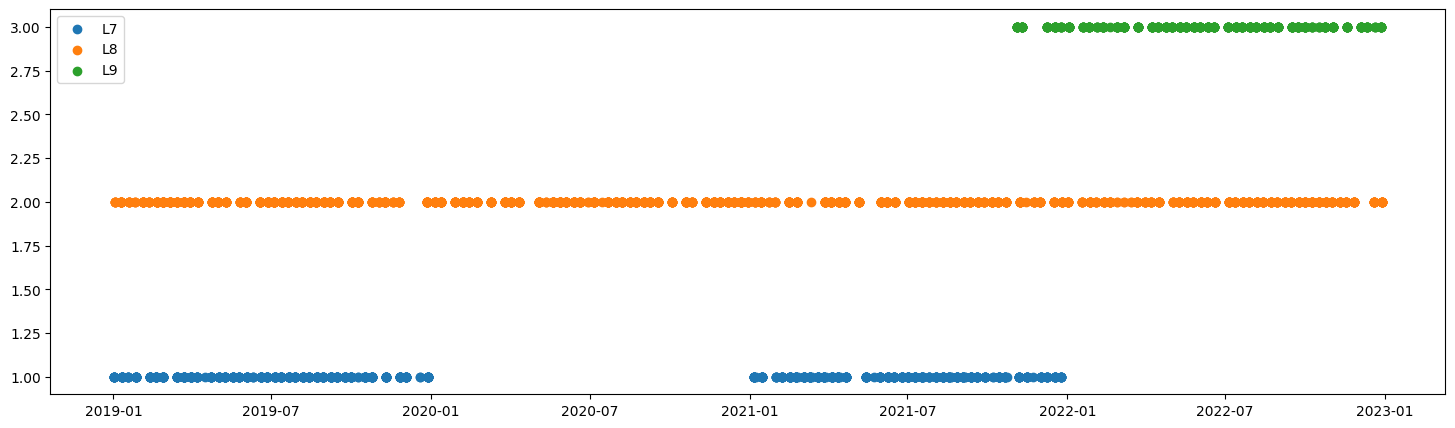

In [239]:
plt.figure(figsize=(18,5))
for i, (sat, group) in enumerate(lst_df.groupby(by="sat")):
    plt.scatter(group.date, [i+1]*len(group), label=sat)
plt.legend()

In [ ]:
date_to_mins=lambda date:date.hour*60+date.minute

# fonction pour afficher plus lisiblement les heures sur le graphique ci-dessous
def format_h(x, pos):
    h = int(x // 60)
    m = int(x % 60)
    return f"{h}h{m:02d}"

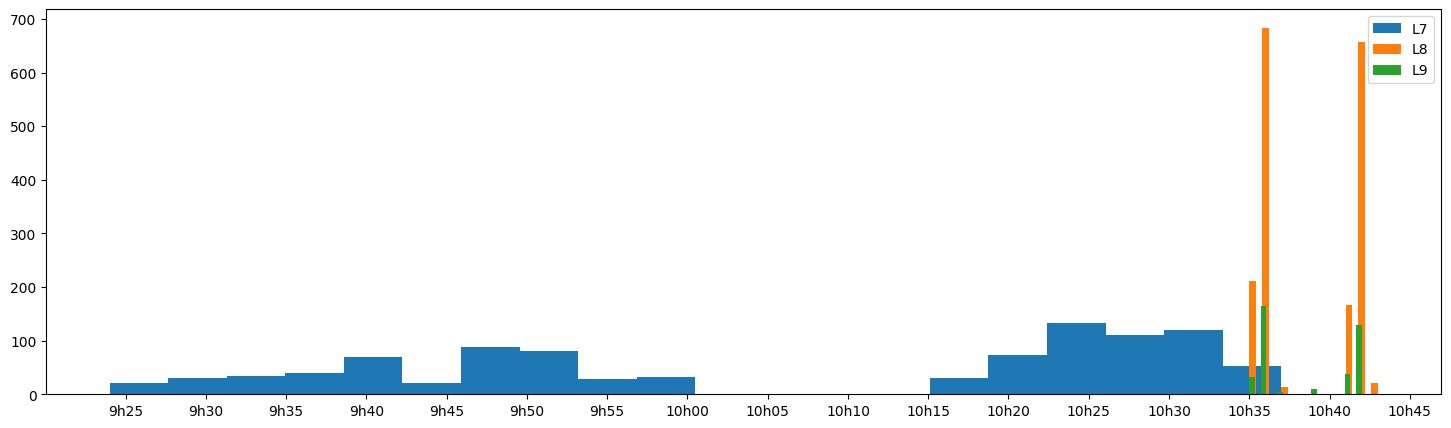

In [246]:
plt.figure(figsize=(18,5))
for i, (sat, group) in enumerate(lst_df.groupby(by="sat")):
    _=plt.hist(group.date.apply(date_to_mins), label=sat, bins=20)
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(format_h))

# création des mosaïques
On veut regrouper toutes les images appartennant à la même acquisition pour en faire des mosaïques à la taille de la haute garonne

### rasterization hg

In [ ]:
hg_fp="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/emprise_haute_garonne/haute_garonne.shp"
hg=gpd.read_file(hg_fp).to_crs(epsg=4326).geometry.tolist()[0]
example_transform=chunks[0]["transform"]
hg_relative_to_example_window=windows.from_bounds(*hg.bounds, transform=example_transform).round_offsets().round_lengths()

hg_transform=windows.transform(hg_relative_to_example_window, example_transform)
hg_mask=rasterize(
    shapes=[(hg, 1)],
    out_shape=(hg_relative_to_example_window.height, hg_relative_to_example_window.width),
    transform=hg_transform,
    fill=0,
    dtype="uint8"
)

## assemblage des chunks spatiaux des mêmes acquisitions

In [299]:
# fonction pour ajuster une image lst sur la grille commune définie à partir du shp de la Haute-Garonne
def merge_and_adjust_to_canvas(img_tens_list : list, transform_list : Affine, canvas_transform : Affine, canvas_shape : tuple) -> torch.Tensor:
    torch.no_grad()
    full_grid=torch.full(canvas_shape, torch.nan, dtype=img_tens_list[0].dtype)
    
    for img_tens, transform in zip(img_tens_list, transform_list):
        transform=torch.tensor(transform).reshape((3,3))
        ll, cc=torch.meshgrid(torch.arange(img_tens.shape[0]), torch.arange(img_tens.shape[1]))
        img_mat_coords=torch.stack([cc.ravel(), ll.ravel(), torch.ones((ll.shape[0]*ll.shape[1]))])

        img_geo_coords=transform@img_mat_coords
        canvas_transform_tens=torch.tensor(canvas_transform).reshape((3,3))
        img_canvas_mat_coords=torch.linalg.inv(canvas_transform_tens)@img_geo_coords
        img_canvas_mat_coords=torch.round(img_canvas_mat_coords).type(torch.int)
        img_canvas_mat_coords=img_canvas_mat_coords.reshape((3, img_tens.shape[0], img_tens.shape[1]))

        in_canvas=torch.all((img_canvas_mat_coords>=torch.tensor([0, 0, 1])[:, None, None]) & (img_canvas_mat_coords<=torch.tensor([canvas_shape[1]-1, canvas_shape[0]-1, 1])[:, None, None]), dim=0)
        valid_coords=torch.where(in_canvas)
        img_valid_mat_coords=img_canvas_mat_coords[:, valid_coords[0], valid_coords[1]]

        full_grid[img_valid_mat_coords[1], img_valid_mat_coords[0]]=img_tens[in_canvas]
    return full_grid

In [300]:
# fonction pour récupérer l'image correspondant à une ligne de lst_df
def get_img(idx):
    lengths=[len(chunk["imgs"]) for chunk in chunks]
    cumsum=[0]+np.cumsum(lengths).tolist()
    bornes=list(zip(cumsum[:-1], cumsum[1:]))
    chunk_id=torch.argmax(torch.tensor([(idx>=borne[0]) & (idx<borne[1]) for borne in bornes]).type(torch.int)).item()
    band_id=idx-cumsum[chunk_id]
    return chunks[chunk_id]["imgs"][band_id]

In [ ]:
# fonction pour récupérer la transformation de géroréférencement à partir de l'id d'un chunk
def get_transform(idx):
    lengths=[len(chunk["imgs"]) for chunk in chunks]
    cumsum=[0]+np.cumsum(lengths).tolist()
    bornes=list(zip(cumsum[:-1], cumsum[1:]))
    chunk_id=torch.argmax(torch.tensor([(idx>=borne[0]) & (idx<borne[1]) for borne in bornes]).type(torch.int)).item()
    return chunks[chunk_id]["transform"]

In [ ]:
full_imgs=[]
full_imgs_noms=[]
for nom, group in tqdm(lst_df.groupby(by="noms")):
    full_imgs.append(merge_and_adjust_to_canvas([get_img(idx) for idx in group.index], [get_transform(idx) for idx in group.index], hg_transform, hg_mask.shape))
    full_imgs_noms.append(nom)
full_imgs_stack=torch.stack(full_imgs)
backup_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/backup"
joblib.dump(full_imgs_stack, join(backup_folder, "images_reassemblees.pkl"))
joblib.dump(full_imgs_noms, join(backup_folder, "noms_images_reassemblees.pkl"))
# charger toutes les images prend 8 minutes
backup_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/backup"
full_imgs=joblib.load(join(backup_folder, "images_reassemblees.pkl"))
full_imgs_noms=joblib.load(join(backup_folder, "noms_images_reassemblees.pkl"))

# Image de nombre d'acquisitions

In [35]:
batch_size=50
i=0
n_acquisitions_img=torch.full((full_imgs.shape[1:]), 0, dtype=torch.int)
while i*batch_size<=len(full_imgs):
    n_acquisitions_img=n_acquisitions_img+torch.sum(~torch.isnan(full_imgs[i*batch_size: min(len(full_imgs), (i+1)*batch_size)]), dim=0)
    i=i+1

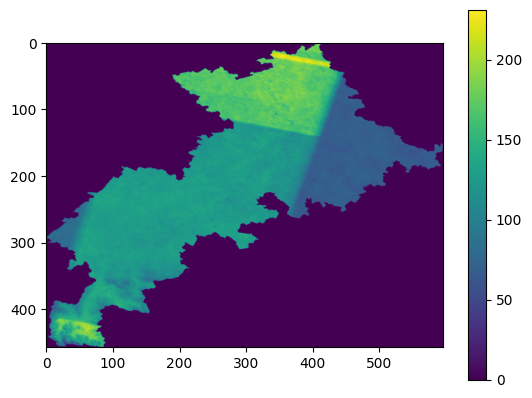

In [36]:
plt.imshow(shreklib.downsample_img(n_acquisitions_img.type(torch.float)))
plt.colorbar()

In [ ]:
shreklib.tif_export(n_acquisitions_img.numpy(), np.array(hg_transform).reshape((3,3)), 4326, "/mnt/RAM_disk/image_nombre_d_acquisitions_lst_landsat.tif", "np.uint8")

## nombre d'acquisitions par mois et sans les images l7

In [ ]:
full_imgs_df=pd.DataFrame({"noms":full_imgs_noms})
full_imgs_df["sat"]=full_imgs_df.noms.apply(parse_sat)
full_imgs_df["date"]=full_imgs_df.noms.apply(parse_date)
full_imgs_df["mois"]=full_imgs_df.date.apply(lambda date:date.month)
full_imgs_df["year"]=full_imgs_df.date.apply(lambda date:date.year)
acquisitions_mensuelles={}
for mois, group in full_imgs_df[full_imgs_df.sat!="L7"].groupby(by=["year","mois"]):
    acquisitions_mensuelles[mois]=torch.sum(~torch.isnan(full_imgs[group.index]), dim=0)

Text(0.5, 0.92, "Nombre d'acquisitions L8 et L9 par mois en 2019")

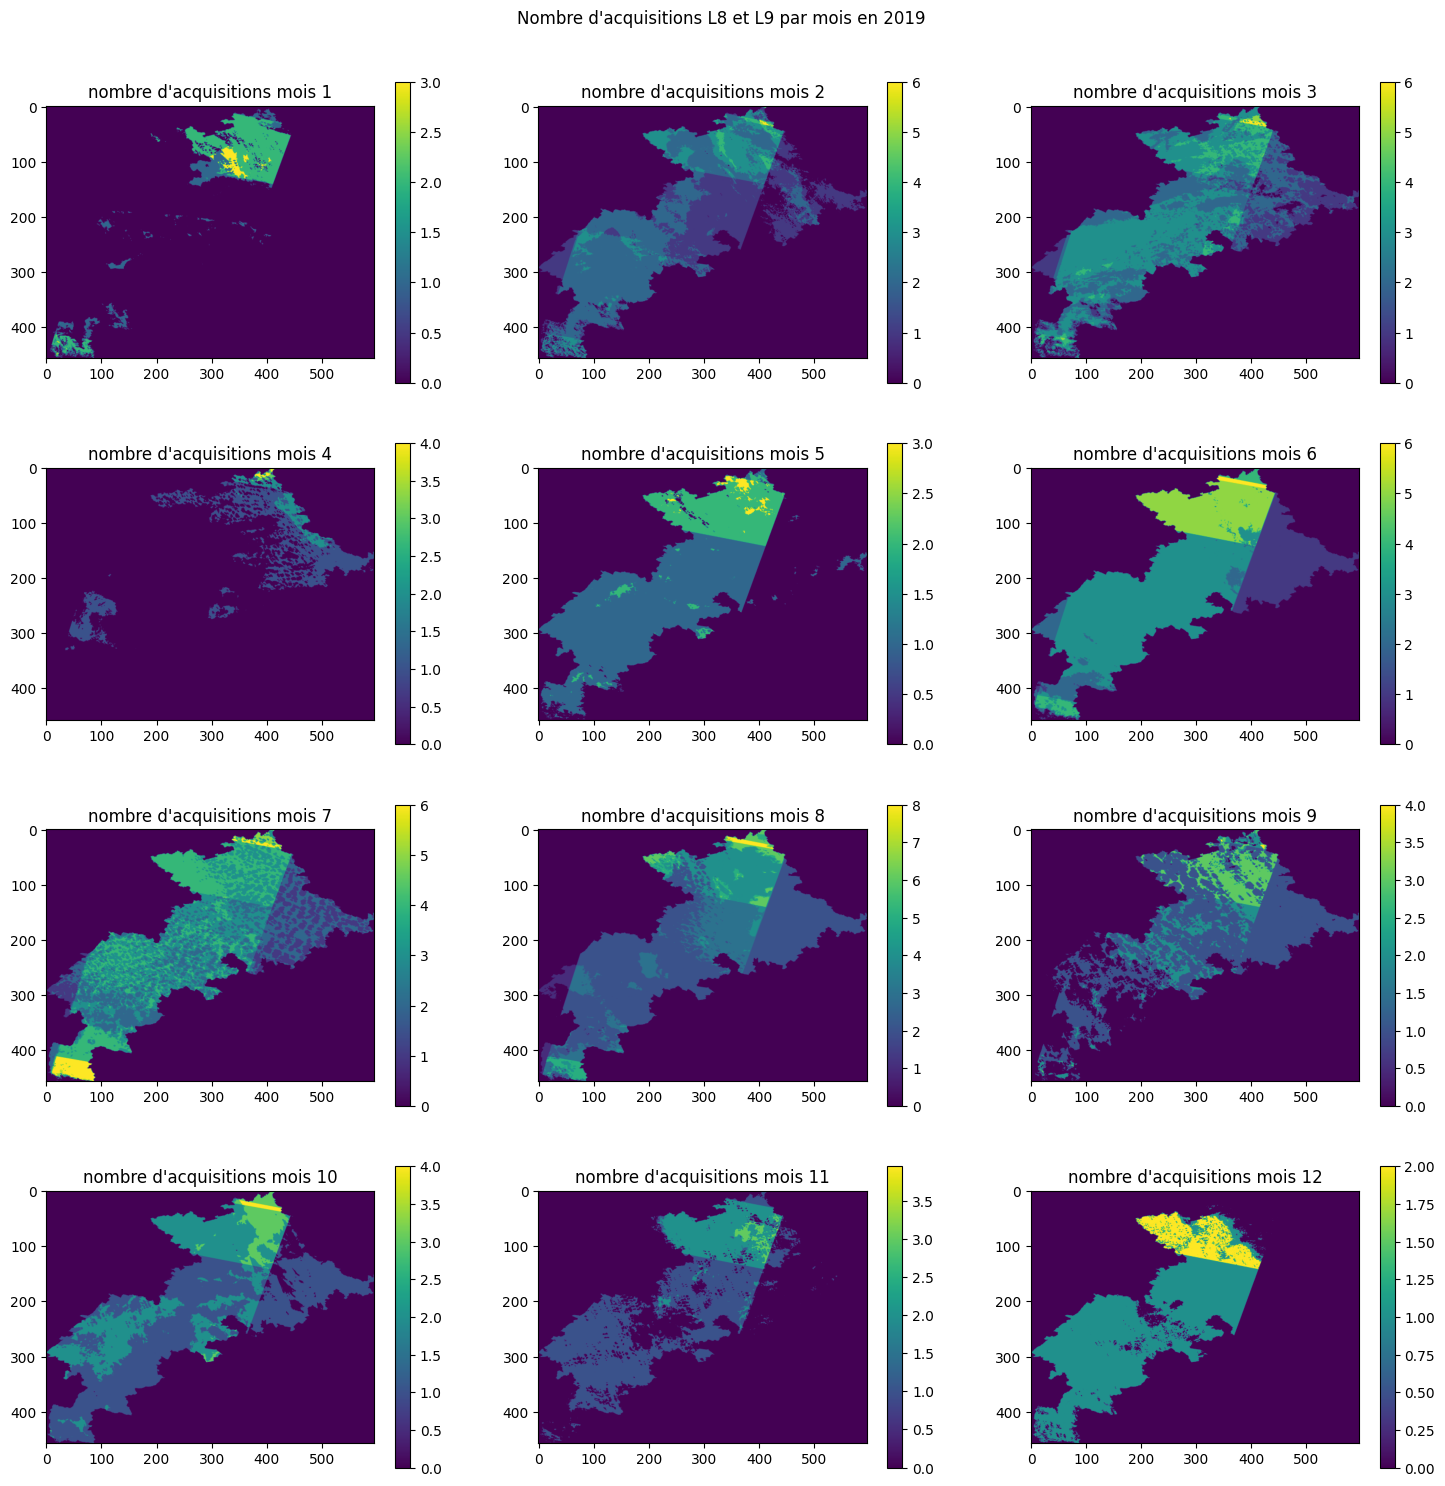

In [85]:
annee_mosaic=2019
plt.figure(figsize=(18,18))
for img, (annee, mois) in [(img, key) for key, img in acquisitions_mensuelles.items() if key[0]==annee_mosaic]:
    plt.subplot(4,3,mois)
    plt.imshow(shreklib.downsample_img(img.type(torch.float)))
    plt.colorbar()
    plt.title(f"nombre d'acquisitions mois {mois}")
plt.suptitle(f"Nombre d'acquisitions L8 et L9 par mois en {annee_mosaic}", y=0.92)

Text(0.5, 0.92, "Nombre d'acquisitions L8 et L9 par mois en 2020")

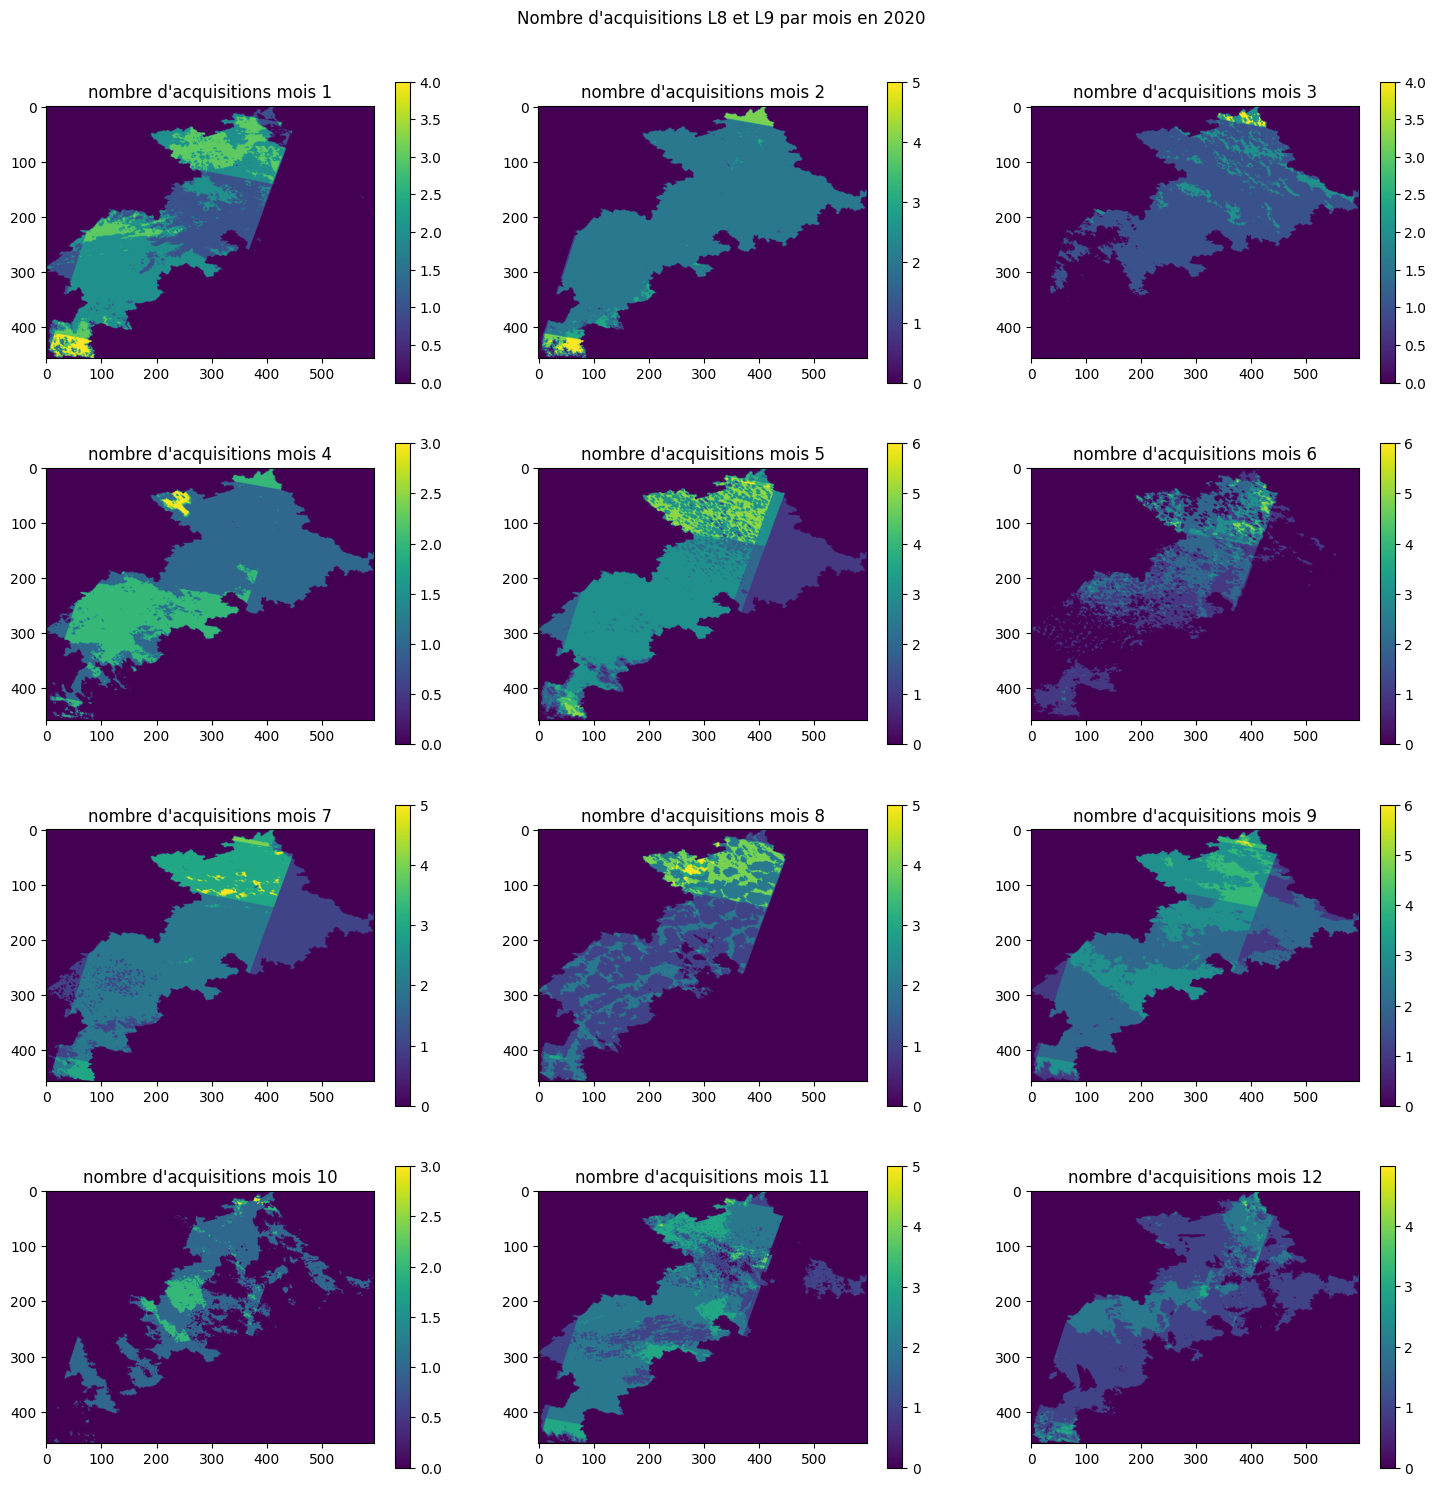

In [86]:
annee_mosaic=2020
plt.figure(figsize=(18,18))
for img, (annee, mois) in [(img, key) for key, img in acquisitions_mensuelles.items() if key[0]==annee_mosaic]:
    plt.subplot(4,3,mois)
    plt.imshow(shreklib.downsample_img(img.type(torch.float)))
    plt.colorbar()
    plt.title(f"nombre d'acquisitions mois {mois}")
plt.suptitle(f"Nombre d'acquisitions L8 et L9 par mois en {annee_mosaic}", y=0.92)

Text(0.5, 0.92, "Nombre d'acquisitions L8 et L9 par mois en 2021")

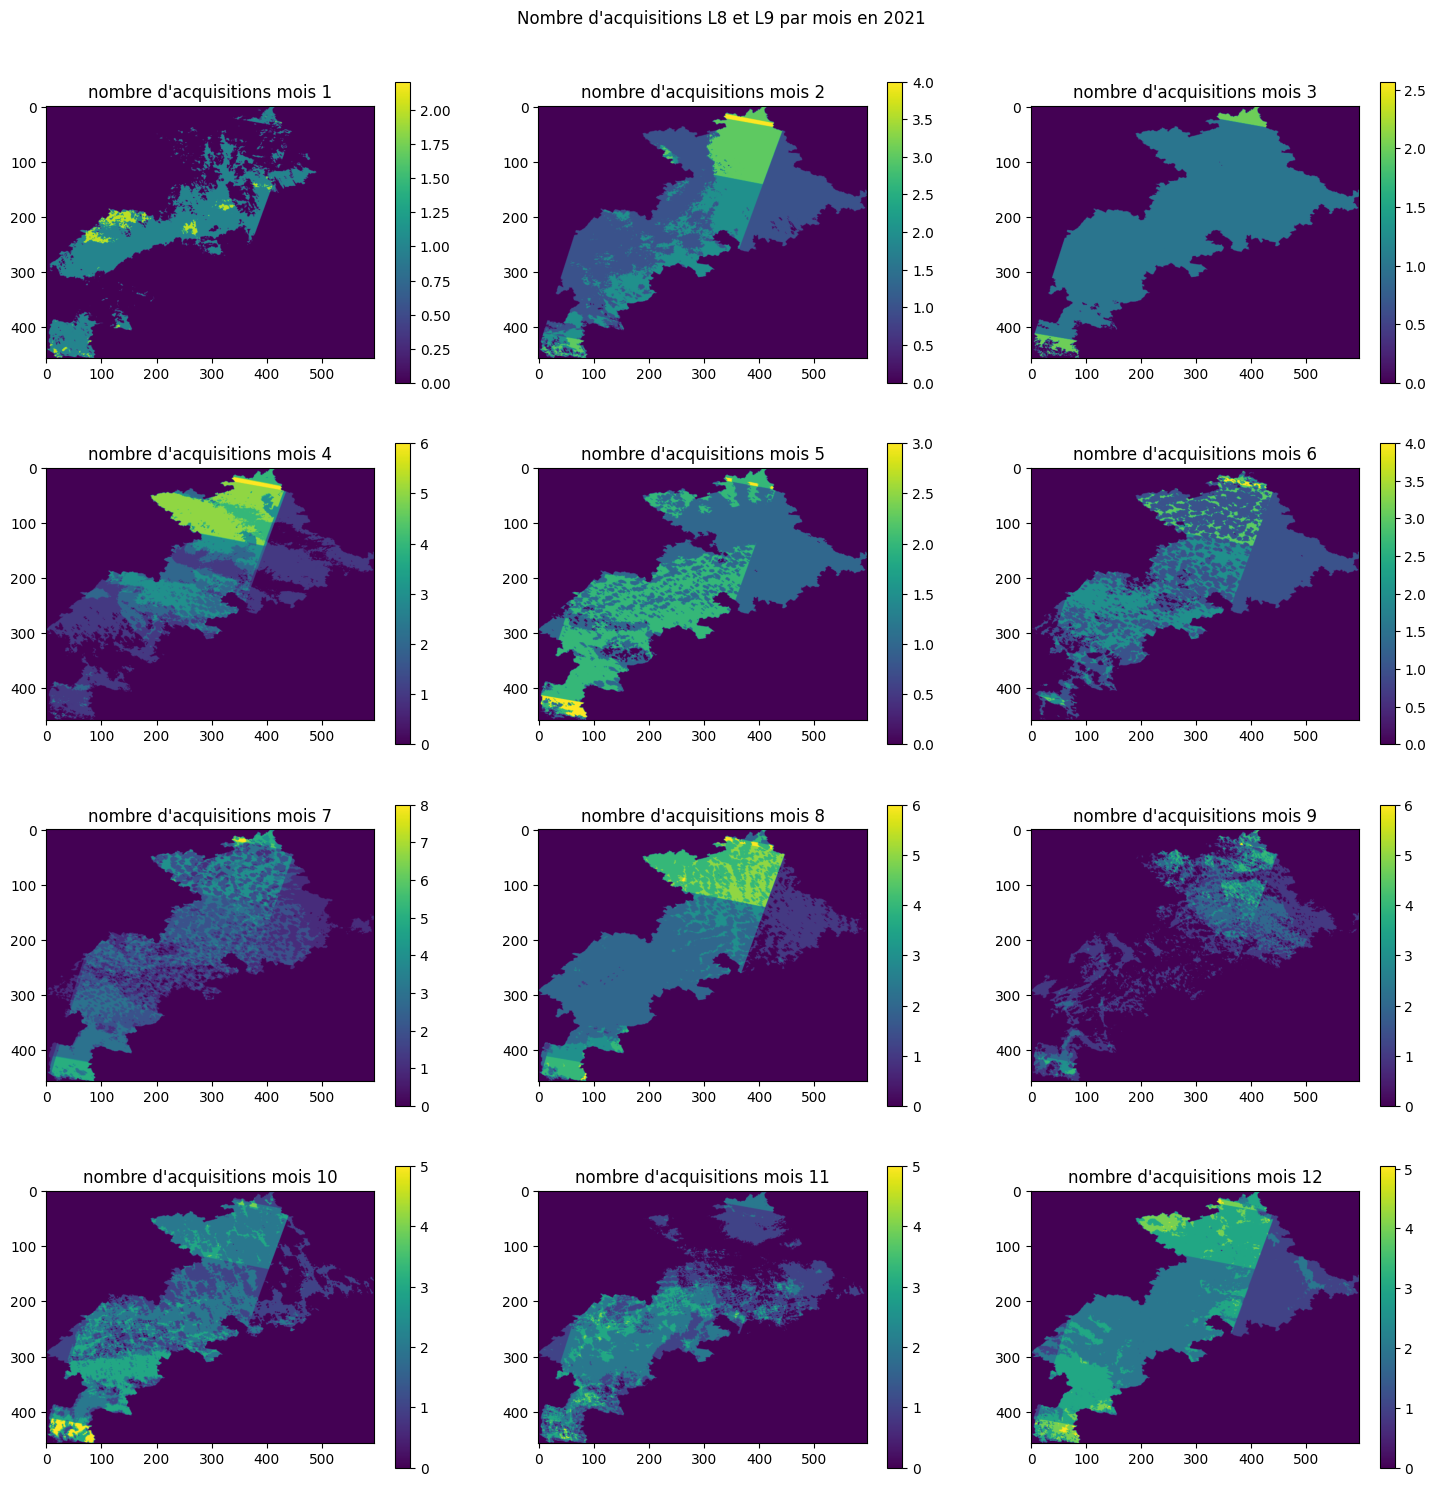

In [87]:
annee_mosaic=2021
plt.figure(figsize=(18,18))
for img, (annee, mois) in [(img, key) for key, img in acquisitions_mensuelles.items() if key[0]==annee_mosaic]:
    plt.subplot(4,3,mois)
    plt.imshow(shreklib.downsample_img(img.type(torch.float)))
    plt.colorbar()
    plt.title(f"nombre d'acquisitions mois {mois}")
plt.suptitle(f"Nombre d'acquisitions L8 et L9 par mois en {annee_mosaic}", y=0.92)

Text(0.5, 0.92, "Nombre d'acquisitions L8 et L9 par mois en 2022")

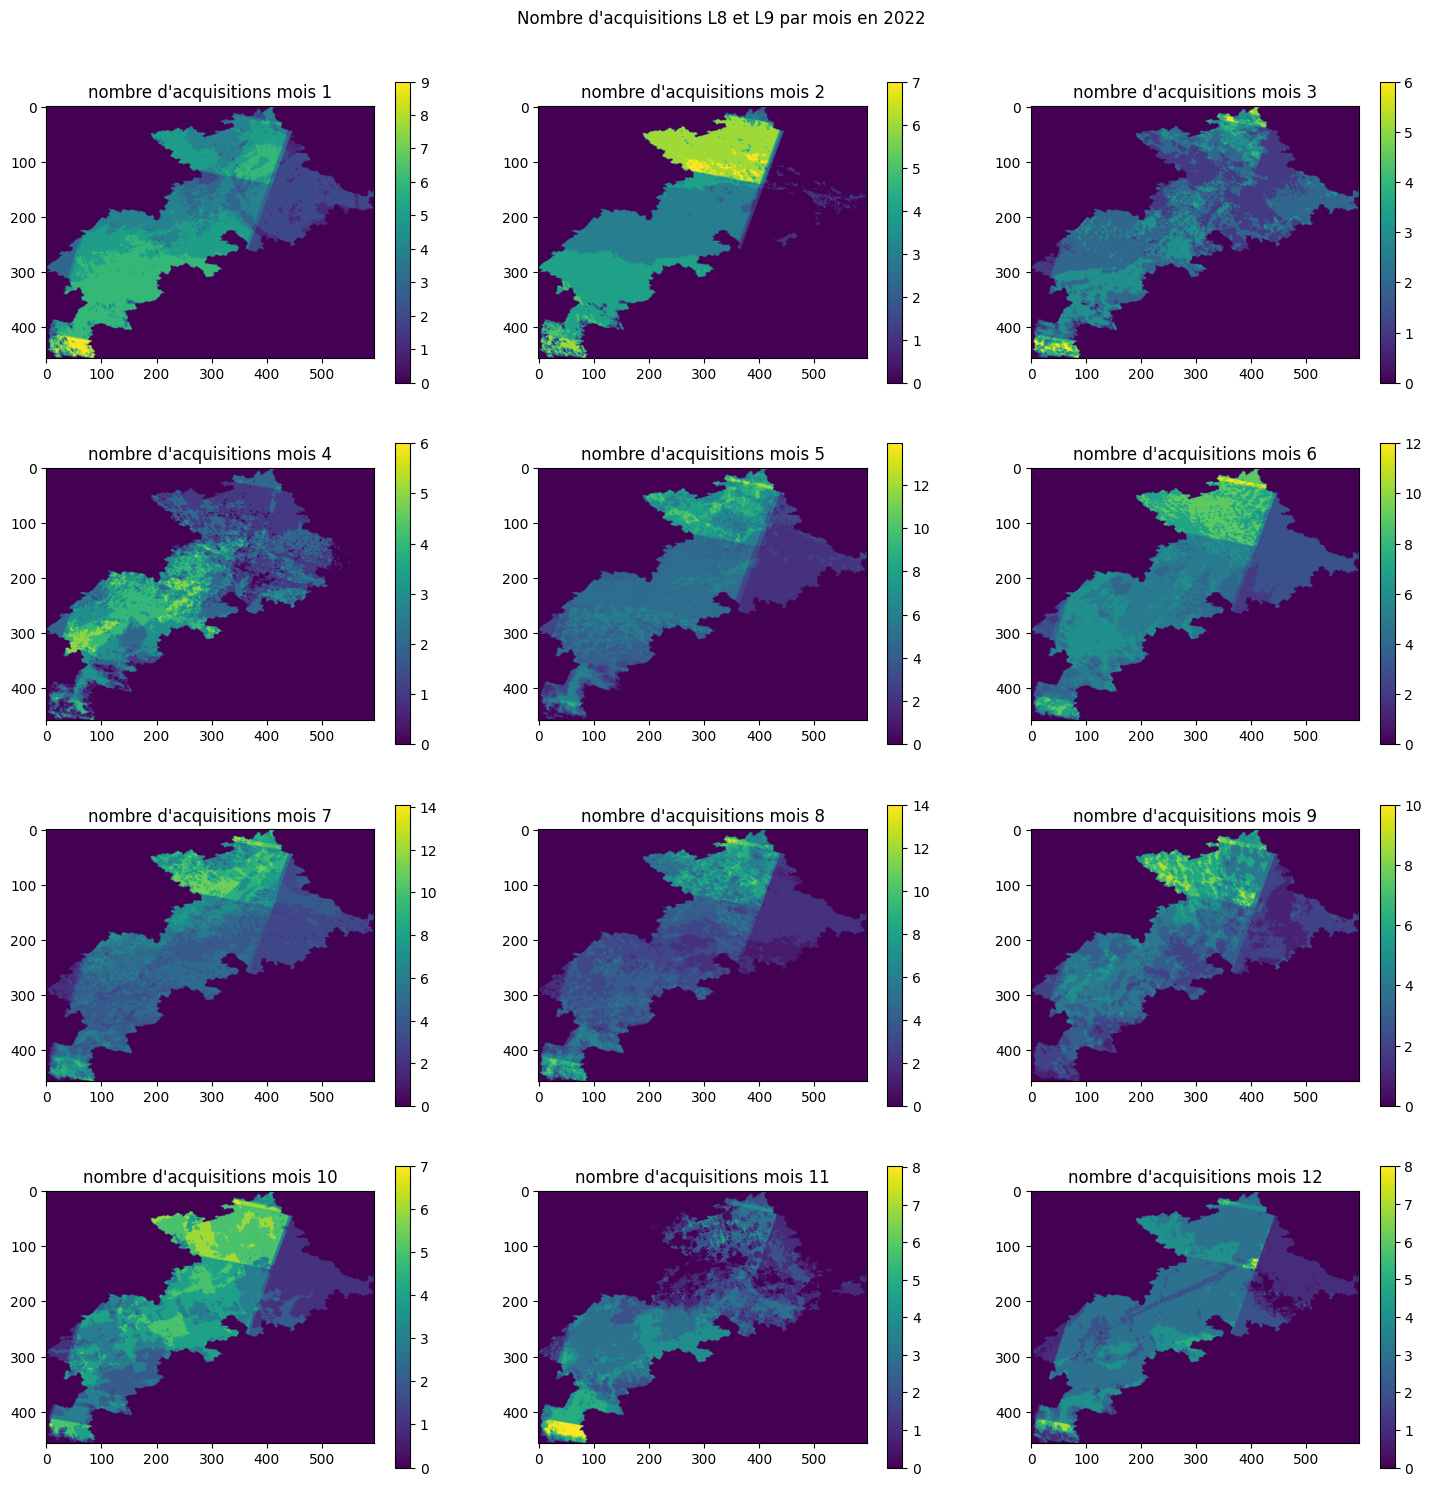

In [88]:
annee_mosaic=2022
plt.figure(figsize=(18,18))
for img, (annee, mois) in [(img, key) for key, img in acquisitions_mensuelles.items() if key[0]==annee_mosaic]:
    plt.subplot(4,3,mois)
    plt.imshow(shreklib.downsample_img(img.type(torch.float)))
    plt.colorbar()
    plt.title(f"nombre d'acquisitions mois {mois}")
plt.suptitle(f"Nombre d'acquisitions L8 et L9 par mois en {annee_mosaic}", y=0.92)

# export des géographies des différentes tuiles

In [ ]:
parse_orbit=lambda nom:nom.split("_")[-1]
full_imgs_df["orbit"]=full_imgs_df.noms.apply(parse_orbit)
shreklib.tif_export(full_imgs[group.index].numpy().astype(float), np.array(hg_transform).reshape((3,3)), 4326, f"/mnt/RAM_disk/{orbit}.tif", "uint8")
wrs2_fp="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/landsat_lst_dates_paths_2019_2022/WRS2_descending_0/WRS2_descending.shp"
wrs2=gpd.read_file(wrs2_fp)
parse_path=lambda orbit:int(orbit[1:4])
parse_row=lambda orbit:int(orbit[5:])
paths=list(map(parse_path,full_imgs_df[full_imgs_df.sat!="L7"].orbit.unique().tolist()))
rows=list(map(parse_row,full_imgs_df[full_imgs_df.sat!="L7"].orbit.unique().tolist()))
full_imgs_df[full_imgs_df.sat!="L7"].orbit.unique().tolist()
np.unique(np.all(np.isin(wrs2[["PATH", "ROW"]].values, list(zip(paths, rows))), axis=1), return_counts=True)
orbit_df=pd.DataFrame({"PATH":paths, "ROW":rows})
wrs2_hg=wrs2.merge(orbit_df, on=["PATH", "ROW"])
wrs2_hg.to_file("/mnt/RAM_disk/orbites_hg_landsat.shp")

# extraction des images des bons satellites, orbites et zone d'étude

In [ ]:
# calcul de l'intersection
rois=wrs2.merge(pd.DataFrame({"PATH":[198,199], "ROW":[30,30]}), on=["PATH", "ROW"])
roi=shapely.intersection(rois.geometry.tolist()[0], rois.geometry.tolist()[1])
# calcul des coordonnées de la grille de réf correspondant à la bbox de roi
cmin, cmax, lmin, lmax=np.round(np.sort(np.clip((np.linalg.inv(np.array(hg_transform).reshape((3,3)))@np.stack([*np.array(roi.bounds).reshape((2,2)).T, np.array([1,1])]))[:-1], np.array([0,0])[:,None], (np.array(hg_mask.shape)[::-1]-1)[:, None]), axis=1).ravel()).astype(int)
#extraction des images du bonne orbite et à l'emprise du roi
img_sample=full_imgs[np.isin(full_imgs_df.orbit, ["P198R030", "P199R030"]) & (full_imgs_df.sat!="L7")][:,lmin:lmax,cmin:cmax]
sample_df=full_imgs_df[np.isin(full_imgs_df.orbit, ["P198R030", "P199R030"]) & (full_imgs_df.sat!="L7")]

## images extrêmes
On sélectionne les images couvrant plus de 20% de la haute garonne et on affiche l'histogramme des températures. Puis on affiche les images de températures extrêmes, qui peuvent être plus contrastées.

In [ ]:
hg_coords=np.where(hg_mask[lmin:lmax,cmin:cmax])
taux_de_couverture=torch.mean((~torch.isnan(img_sample[:, hg_coords[0], hg_coords[1]])).type(torch.float), dim=(1))
t_mean=torch.nanmean(img_sample[taux_de_couverture>0.2].type(torch.float64), dim=(1,2))

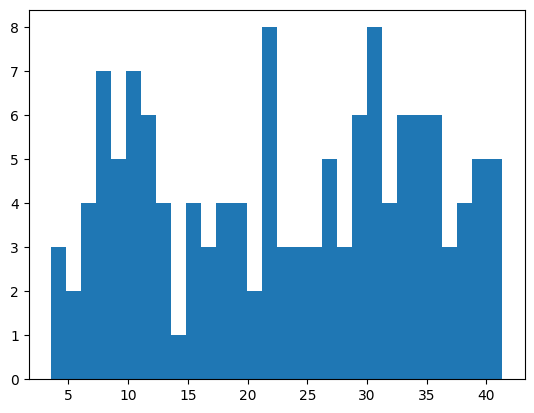

In [252]:
_=plt.hist(t_mean, bins=30)

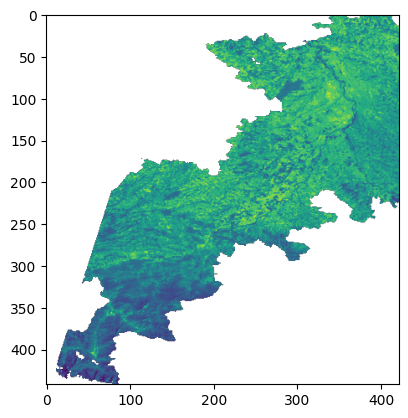

In [256]:
plt.imshow(shreklib.downsample_img(img_sample[taux_de_couverture>0.2][t_mean>=np.percentile(t_mean,98)][0]))

In [ ]:
roi_origin=np.array(hg_transform).reshape((3,3))@np.array([cmin, lmin, 1])
roi_transform=np.array(hg_transform).reshape((3,3)).copy()
roi_transform[:,-1]=roi_origin
for img, t in zip(img_sample[taux_de_couverture>0.2][t_mean>=np.percentile(t_mean,98)], t_mean[t_mean>=np.percentile(t_mean,98)]):
    shreklib.tif_export(img.type(torch.float).numpy(), roi_transform, 4326, f"/mnt/RAM_disk/mean_temp_{t}.tif")

## Séries Temporelles LST
On veut afficher les séries temporelles des pixels de zone humide vs les autres.  
Pour cela, on se restreint à une partie des images, correspondant à l'intersection des images 198 30 et 199 30.

In [ ]:
from rasterio.features import rasterize
from affine import Affine
roi_raster=rasterize(
    shapes=(roi, 1),
    out_shape=(lmax-lmin, cmax-cmin),
    fill=0,
    transform=Affine(*roi_transform.ravel()[:6])
)
# on masque les images du sample
img_sample[:,~roi_raster.astype(bool)]=torch.nan

## on rasterise les zones humides de la zone d'étude

In [ ]:
# les zones humides du CD sont déjà en 4326
zhs_fp="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/donnees_reference/Inventaire_HG_2016/zones_humides.shp"
zhs=gpd.read_file(zhs_fp)
shapes=((zh, 1) for zh in zhs.geometry)
zhs_raster=rasterize(
    shapes=shapes,
    transform=Affine(*roi_transform.ravel()[:6]),
    out_shape=(lmax-lmin, cmax-cmin),
    fill=0
)

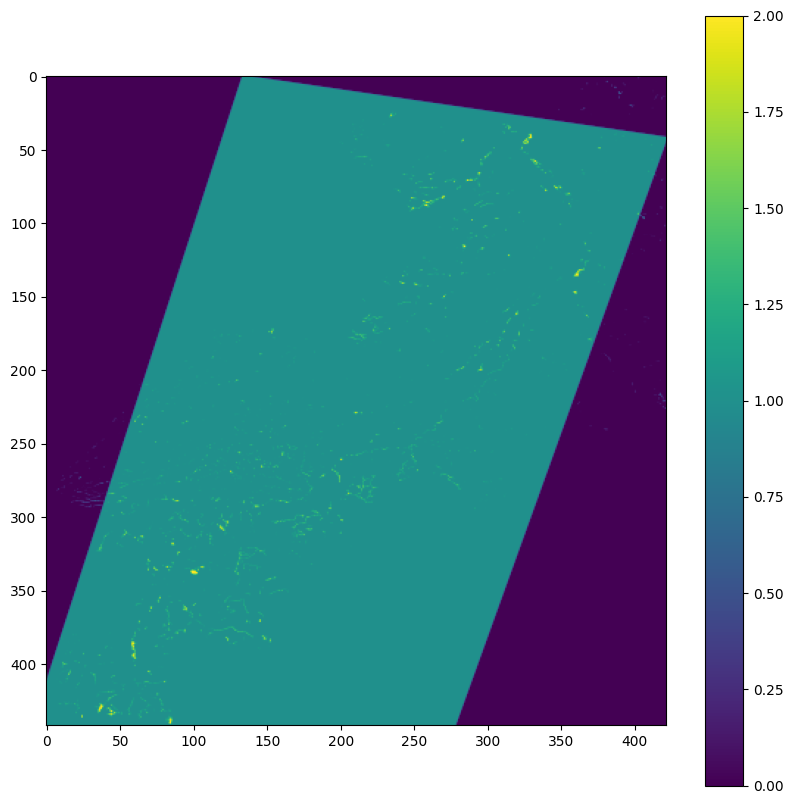

In [299]:
plt.figure(figsize=(10,10))
plt.imshow(shreklib.downsample_img(roi_raster+zhs_raster))
plt.colorbar()

In [ ]:
zhs_st=img_sample[:,zhs_raster.astype(bool)]
#on supprime les st qui ne sont que des nans. Ce qui correspond aux zh en dehors du roi.
zhs_st_nanned=zhs_st[:, ~torch.all(torch.isnan(zhs_st), dim=0)]
zhs_st_sample_idx=np.random.choice(len(zhs_st_nanned.T), size=100, replace=False)
zhs_st_sample=zhs_st_nanned[:,zhs_st_sample_idx]
zhs_st_sample_ordered=zhs_st_sample[sample_df.reset_index(drop=True).sort_values(by="date").index]
znh_st=img_sample[:, ~zhs_raster.astype(bool)]
znh_st=znh_st[:,~torch.all(torch.isnan(znh_st), dim=0)]
znh_st_sample=znh_st[:,np.random.choice(znh_st.shape[1], size=100, replace=False)]
znh_st_sample_ordered=znh_st_sample[sample_df.reset_index(drop=True).sort_values(by="date").index]
nan_mask=torch.isnan(zhs_st_sample_ordered[:,0])
dates=sample_df.sort_values(by="date").date.values
interpolated_values=np.interp(
    dates.astype(float)[nan_mask],
    dates.astype(float)[~nan_mask],
    zhs_st_sample_ordered[:,0][~nan_mask]
)
example_interpolated=zhs_st_sample_ordered[:,0].numpy().copy()
example_interpolated[nan_mask]=interpolated_values

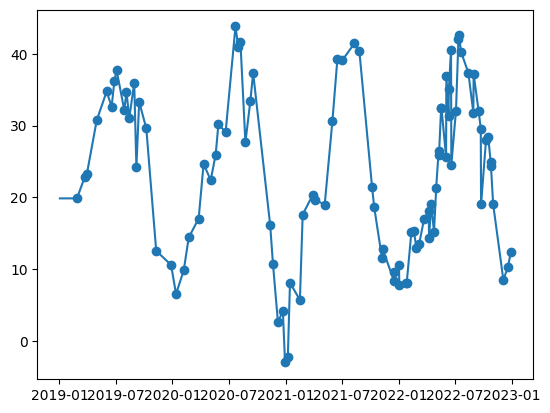

In [363]:
plt.plot(dates, example_interpolated)
plt.scatter(dates, zhs_st_sample_ordered[:,0])

# Export des images pour l'API interrogée par une page web de visualisation

In [ ]:
from PIL import Image
img256=roi_mean.numpy().astype(float)
min=np.nanmin(img256)
max=np.nanmax(img256)
img256=((img256-min)/(max-min))*255

img256_nanned=np.nan_to_num(img256,0).astype(np.uint8)
nan_transparency=((~torch.isnan(roi_mean))*255).numpy()
img_rgba=np.stack([img256_nanned, np.zeros_like(img256_nanned), np.zeros_like(img256_nanned), nan_transparency]).astype(np.uint8)
pil=Image.fromarray(img256)
pil.save("visu_lst_landsat/data/lst_mean.jpeg")
pil=Image.fromarray(np.transpose(img_rgba, (1,2,0)), mode="RGBA")
pil.save("visu_lst_landsat/data/lst_mean.png")
zhs[["nom", "geometry"]].to_file("./visu_lst_landsat/data/zh.geojson")
valid_coords_mask=np.all(np.stack([roi_raster, hg_mask[lmin:lmax,cmin:cmax]]).astype(bool), axis=0)
is_valid=valid_coords_mask[l,c]
st=img_sample[:,l,c]
st=st[~torch.isnan(st)]
img_sample_ordered=img_sample[sample_df.reset_index().sort_values(by="date").index]
sample_df_ordered=sample_df.sort_values(by="date").reset_index(drop=True)
out_folder="visu_lst_landsat/data"
torch.save(img_sample_ordered.detach(), join(out_folder, "img_stack.pt"))
sample_df_ordered.to_pickle(join(out_folder, "img_meta.pkl"))
np.save(join(out_folder, "valid_coords.npy"), valid_coords_mask)
np.save(join(out_folder, "stack_transform.npy"), roi_transform)

# on rajoute la carto reauzoh 3 au projet de visualisation

In [557]:
r3_montagne_fp="/mnt/RAM_disk/reauzoh3_montagne_6mois_sieve10_8conx.tif"
r3_plaine_fp="/mnt/RAM_disk/reauzoh3_plaine_6mois_sieve10_8conx.tif"

In [559]:
with rasterio.open(r3_montagne_fp, "r") as src:
    r3_montagne=src.read(1)

with rasterio.open(r3_plaine_fp, "r") as src:
    r3_plaine=src.read(1)

In [562]:
r3=r3_montagne+r3_plaine

## reprojection en 3857 et export en png (nécessaires pour leaflet)

In [ ]:
from rasterio import warp

with rasterio.open(r3_plaine_fp, "r") as src:
    r3_bounds=src.bounds
    r3_transform=src.transform
r3_3857_transform, width3857, height3857=warp.calculate_default_transform(
    32631,
    3857,
    r3.shape[1],
    r3.shape[0],
    *r3_bounds
)
r3_3857=np.empty((height3857, width3857), dtype=np.uint8)
warp.reproject(
    source=r3,
    destination=r3_3857,

    src_transform=r3_transform,
    src_crs=32631,

    dst_transform=r3_3857_transform,
    dst_crs=3857,

    resampling=warp.Resampling.nearest
)
r3_3857_rgba=np.stack([np.zeros_like(r3_3857), np.zeros_like(r3_3857), r3_3857*255, r3_3857*128],axis=-1)
r3_pil=Image.fromarray(r3_3857_rgba, mode="RGBA")
r3_pil.save("visu_lst_landsat/data/reauzoh3_3857.png")

# Médianes saisonnières
Pour intégrer les images landsat lst à la carto reauzoh, il semble que les médianes saisonnières sur le roi sont pertinentes.  
On se restreint au roi pour n'avoir que des pixels qui sont couverts par les deux orbites de la Haute-Garonne, et ainsi éviter d'avoir des pixels avec des dates et donc des températures structurellement non alignés.  
En outre, se restreindre à la ligne 30 permet d'avoir les mêmes moments d'acquisition. Une différence de 10 minutes à l'heure assez critique de 10h30, pouvant être un biais en été.  

La médiane saisonnière semble également plus stable que la moyenne mensuelle. La granualarité saisonnière permet d'avoir moins de nodate et également un plus grand nombre d'images, permettant d'espèrer une médiane plus représentative.  
La médiane semble plus adaptée que la moyenne car les lst peuvent fortement varier dans des intervalles très courts, contrairement aux autres bandes optiques.  En prennant la moyenne, on introduit un fort biais aux outliers, qui est lié au fait que des acquisitions outliers vont être nans à certains endroits et pas à d'autres.  

L'observation de la LST semble apporter relativement peu d'info et cette source semble également très biaisée. Ainsi les nans vont introduire des gros écarts entre des profils.  
De la même manière, les régressions sinus linéaires des images ecostress, montrent que même en présence d'une bonne quantité de données, celle-ci peut-être impossible à exploiter du fait d'un échantillonnage temporel indadapté.  
En somme, la grande variabilité temporelle des LST laisse présager qu'il s'agit d'une couche ne portant pas plus d'information que d'autres bandes optiques ou que la combinaison d'indices comme le ndvi et le ndwi tout en étant beaucoup plus incohérente et sujette aux aberrations que ces indices.  

Il semble que la radiométrie soit une mauvaise source pour améliorer la cartographie.  
La prise en compte des séries temporelles semble également être une impasse.  
Il n'y a vraisemblablement pas de spécificité plus fine que celle actuellement extrapolée par le Random Forest, ni radiométrique ni en terme de série temporelle des zones humides.  

Une source beaucoup plus prometteuse d'amélioration est la meilleure prise en compte du contexte.  
Par exemple, la cartographie actuelle identifie des zones humides en plein lotissements urbains. La raison est que ces zones ressemblent, à l'échelle du pixel, tout à fait à des zones humides de végétation basse en plaine. Cependant, leur voisinnage est en revanche absolument dissemblable.    
L'utilisation de modèles prennant en compte le contexte spatial, comme un UNet ou un Swin-Transformer, permettrait d'apprendre que tel profil de zone humide, parmi tous les profils du jeu d'entraînement, est associé à tel environnement. Ainsi, le modèle pourrait apprendre --> ceci est un contexte urbain, les zones humides ressemblent à ça. A une échelle plus locale --> ceci ressemble à un lotissement, dans lesquels il n'y a pas de zones humides.  
Au final, cela permet d'entraîner un seul modèle à comprendre des contextes locaux complexes, au lieu d'avoir à faire des partitions des jeux à la main ou restreindre la zone d'étude pour entraîner un Random Forest.

In [ ]:
get_absolute_season=lambda date:((date.month%12+(date.day-21)/31)//3)%4
get_season=lambda date:((date.month+(date.day-21)/31)//3)+(date.year-2019)*4
sample_df=sample_df.copy()
sample_df["saison"]=sample_df.date.apply(get_season)
sample_df["absolute_season"]=sample_df.date.apply(get_absolute_season)
season_meds={}
i=0
for saison, group in sample_df.reset_index(drop=True).groupby(by="saison"):
    if saison in [0, 16]: #on enlève les bords de la période qui ne correspondent pas à des saisons entières
        continue
    season_meds[saison]=torch.nanmedian(img_sample[group.index], dim=0)

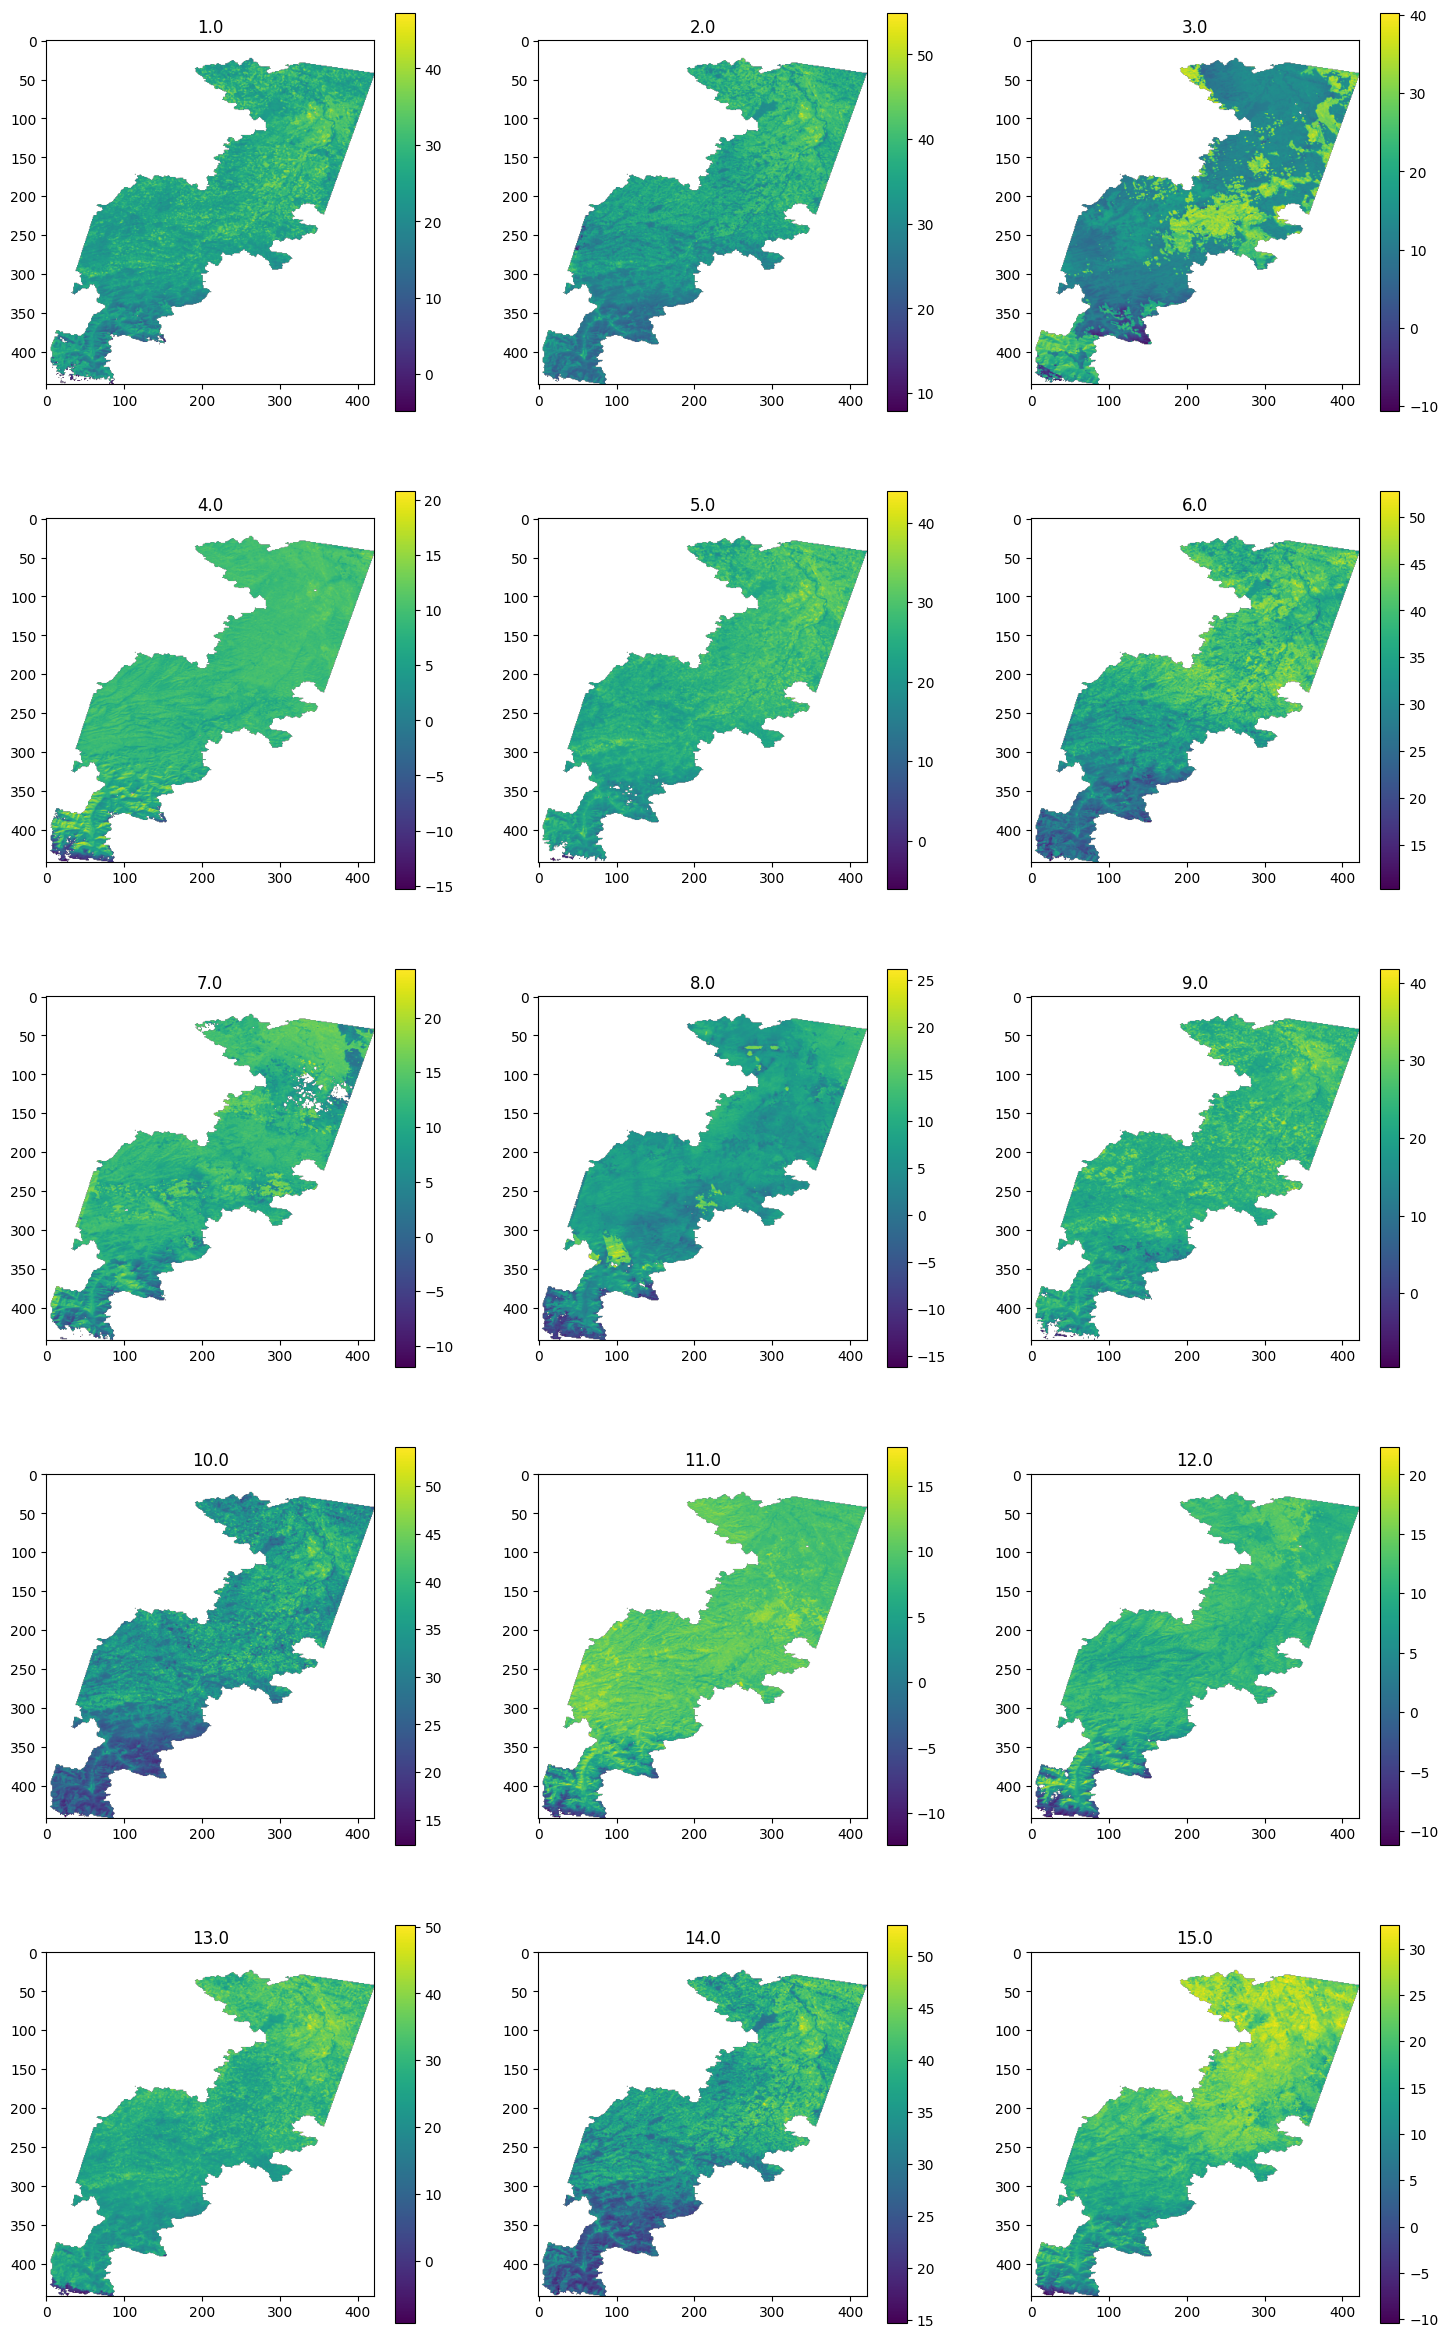

In [712]:
plt.figure(figsize=(18,30))
for saison, img_med in season_meds.items():
    plt.subplot(5,3, int(saison))
    plt.imshow(shreklib.downsample_img(img_med.values))
    plt.colorbar()
    plt.title(str(saison))

In [ ]:
out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/modeles/reauzoh4"
torch.save(torch.stack([img.values for img in season_meds.values()]))
absolute_season_meds={}
for saison, group in sample_df.reset_index(drop=True).groupby(by="absolute_season"):
    absolute_season_meds[saison]=torch.nanmedian(img_sample[group.index], dim=0)
abs_meds_stack=torch.stack([img.values for img in absolute_season_meds.values()])

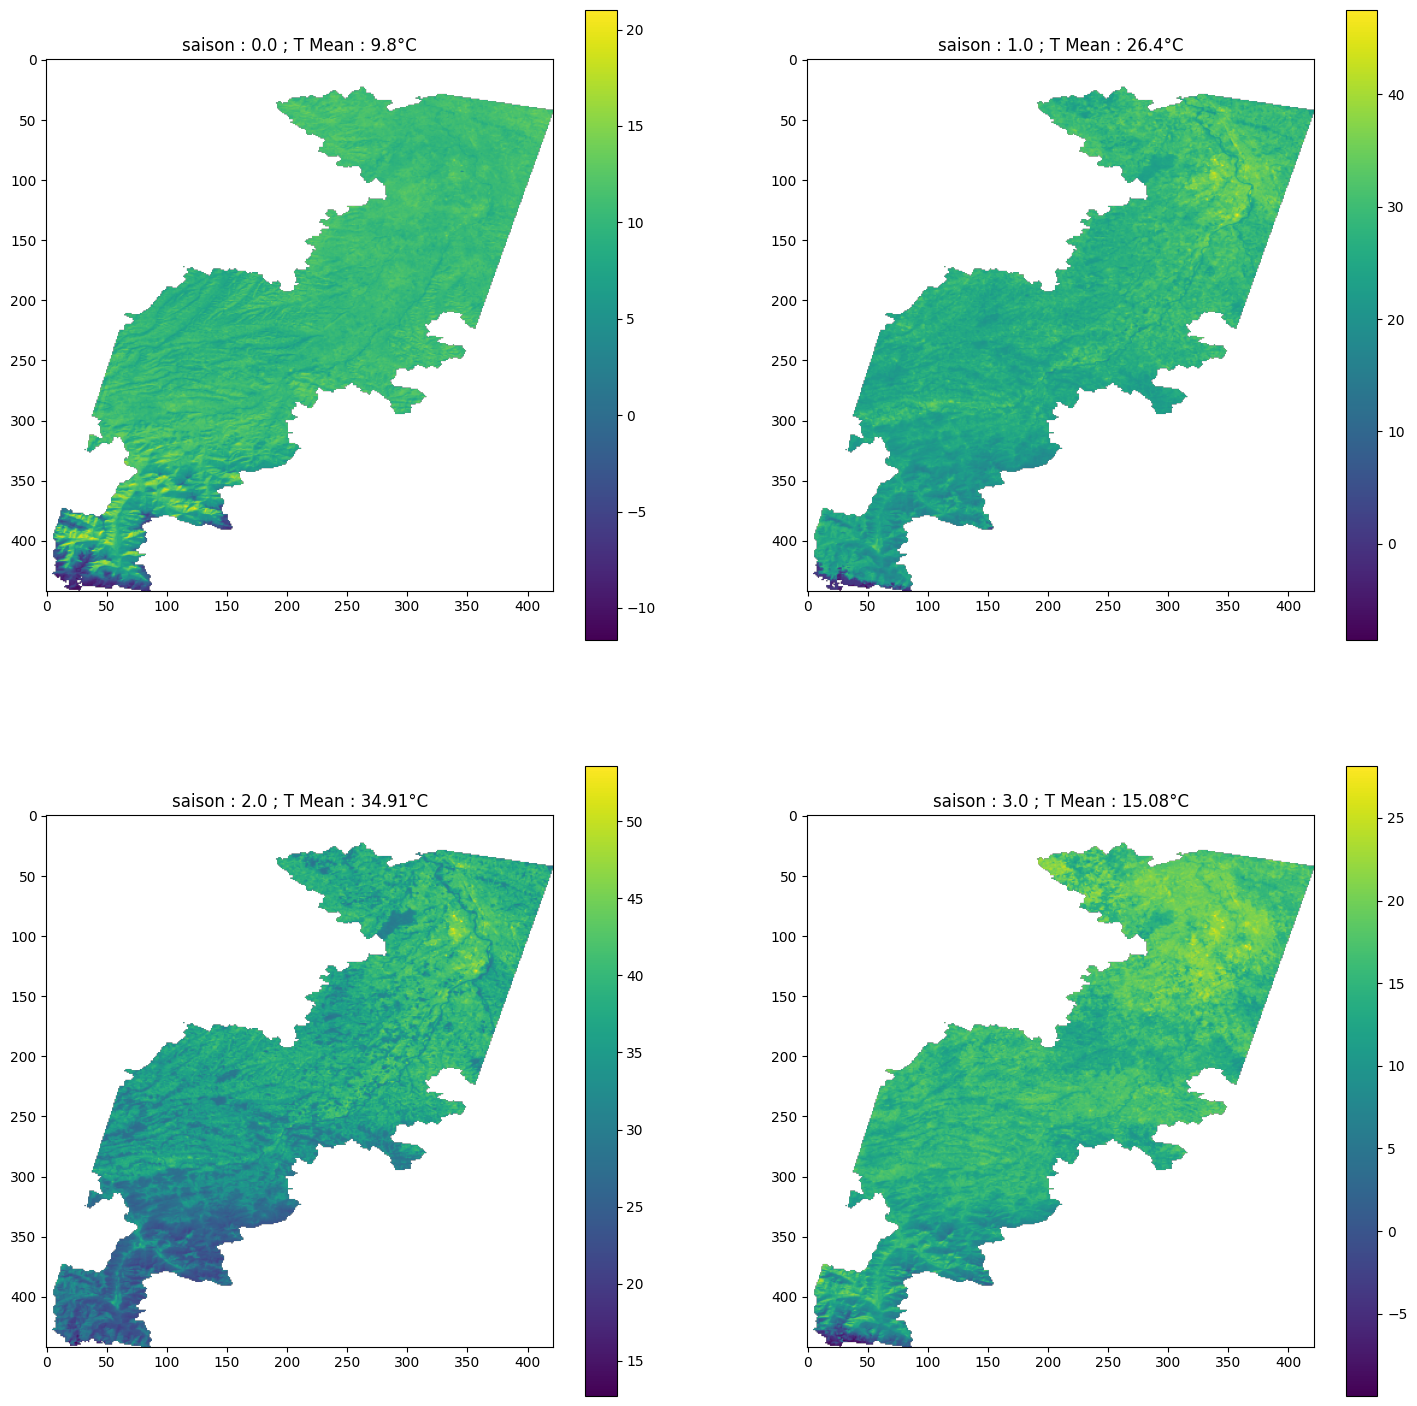

In [ ]:
# est-ce que l'image d'été n'est pas la seule qui est utile?
#les autres ne sont-elles pas la même chose en moins contrasté?
plt.figure(figsize=(18,18))
for i, (saison, img) in enumerate(absolute_season_meds.items()):
    plt.subplot(2,2,i+1)
    plt.imshow(shreklib.downsample_img(img.values))
    plt.title(f"saison : {saison} ; T Mean : {round(torch.nanmean(img.values.type(torch.float64)).item(), 2)}°C")
    plt.colorbar()

# reprojection à la grille de référence du stage et export des médianes saisonnières

In [ ]:
# calcul des bounds
left, bottom, right, top=np.sort(np.stack([roi_transform[:-1,-1],(roi_transform@np.array([abs_meds_stack.shape[2], abs_meds_stack.shape[1], 1]))[:-1]]), axis=0).ravel()
lst_meds_32631=np.full((len(abs_meds_stack),shreklib.ref_grid["height"], shreklib.ref_grid["width"]), np.nan, dtype=np.float64)
warp.reproject(
        source=abs_meds_stack.numpy().astype(np.float64),
        destination=lst_meds_32631,

        src_crs=4326,
        dst_crs=32631,

        src_transform=Affine(*roi_transform.ravel()[:6]),
        dst_transform=Affine(*shreklib.ref_grid["transform"].ravel()[:6]),

        dst_nodata=np.nan,

        num_threads=32,

        resampling=warp.Resampling.bilinear
    )

shreklib.tif_export(lst_meds_32631, shreklib.ref_grid["transform"], 32631, join(out_folder, "lst_medianes_saisonnieres.tif"), "float32")
torch.save(abs_meds_stack, join("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/modeles/reauzoh4", "landsat_lst_season_meds.pt"))